In [1]:
import _referAsMain
import sys; print(sys.version_info)
from datasets import load_dataset
import torch, random, time, math
from IPython.display import SVG, display

added '/home/time/Bureau/pfe/PFE_LLM_art_generation' to import paths
sys.version_info(major=3, minor=10, micro=19, releaselevel='final', serial=0)


/home/time/Bureau/pfe/PFE_LLM_art_generation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

Torch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
Device count: 1


In [3]:
dataset = load_dataset("xingxm/SVGX-SFT-1M", split="train", data_files="SVGX_SFT_GEN_51k.json")

In [4]:
print(len(dataset))

514172


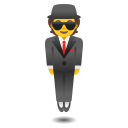

In [5]:
display(SVG(data=dataset[0]["output"]))

In [6]:
import LLM.nanochat.gpt as nanoChatModel
import tokenizer_pfe.tokenizer_project as tokenizerLib
from tokenizer_pfe.tokenizer_project import SPECIAL_TOKENS
from LLM.nanochat.common import compute_init, autodetect_device_type

In [7]:
device_type = "cuda"
device_type = (autodetect_device_type() if device_type == "" else device_type)
ddp, ddp_rank, ddp_local_rank, ddp_world_size, device = compute_init(device_type)

2026-02-23 15:28:07,999 - LLM.nanochat.common - INFO - Distributed world size: 1


In [8]:
tokenizerPreTrained = tokenizerLib.Tokenizer.from_pretrained("gpt2")

2026-02-23 15:28:08,125 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/tokenizer.json "HTTP/1.1 200 OK"


In [9]:
tokenizerTrainedMedium = tokenizerLib.Tokenizer.train_from_iterator(
    dataset[: 25_000]["output"], vocab_size=2048, special_tokens=SPECIAL_TOKENS)

In [10]:
tokenizer = tokenizerTrainedMedium
vocab_size = tokenizer.get_vocab_size()
print(vocab_size)
display(sorted([(id, tk) for tk, id in tokenizer.tokenizer.get_vocab().items()], reverse=False))
OutStart_Token = "<|output_start|>"
OutEnd_Token = "<|output_end|>"
OutEnd_ids = tokenizer.encode(OutEnd_Token); assert len(OutEnd_ids) == 1
OutEnd_id = OutEnd_ids[0]; del OutEnd_ids

1698


[(0, '<|output_start|>'),
 (1, '<|output_end|>'),
 (2, '!'),
 (3, '"'),
 (4, '#'),
 (5, '$'),
 (6, '%'),
 (7, '&'),
 (8, "'"),
 (9, '('),
 (10, ')'),
 (11, '*'),
 (12, '+'),
 (13, ','),
 (14, '-'),
 (15, '.'),
 (16, '/'),
 (17, '0'),
 (18, '1'),
 (19, '2'),
 (20, '3'),
 (21, '4'),
 (22, '5'),
 (23, '6'),
 (24, '7'),
 (25, '8'),
 (26, '9'),
 (27, ':'),
 (28, ';'),
 (29, '<'),
 (30, '='),
 (31, '>'),
 (32, '?'),
 (33, '@'),
 (34, 'A'),
 (35, 'B'),
 (36, 'C'),
 (37, 'D'),
 (38, 'E'),
 (39, 'F'),
 (40, 'G'),
 (41, 'H'),
 (42, 'I'),
 (43, 'J'),
 (44, 'K'),
 (45, 'L'),
 (46, 'M'),
 (47, 'N'),
 (48, 'O'),
 (49, 'P'),
 (50, 'Q'),
 (51, 'R'),
 (52, 'S'),
 (53, 'T'),
 (54, 'U'),
 (55, 'V'),
 (56, 'W'),
 (57, 'X'),
 (58, 'Y'),
 (59, 'Z'),
 (60, '['),
 (61, '\\'),
 (62, ']'),
 (63, '^'),
 (64, '_'),
 (65, '`'),
 (66, 'a'),
 (67, 'b'),
 (68, 'c'),
 (69, 'd'),
 (70, 'e'),
 (71, 'f'),
 (72, 'g'),
 (73, 'h'),
 (74, 'i'),
 (75, 'j'),
 (76, 'k'),
 (77, 'l'),
 (78, 'm'),
 (79, 'n'),
 (80, 'o'),
 (81, 'p'

In [11]:
print(tokenizer.get_special_tokens())

['<|output_start|>', '<|output_end|>']


In [ ]:
tokenizer.save("test_tokenizer_save")

Saved tokenizer to test/tokenizer.json


In [ ]:
token = tokenizer.load("test_tokenizer_save/tokenizer.json")

Load tokenizer {'version': '1.0', 'truncation': None, 'padding': None, 'added_tokens': [{'id': 0, 'content': '<|output_start|>', 'single_word': False, 'lstrip': False, 'rstrip': False, 'normalized': False, 'special': True}, {'id': 1, 'content': '<|output_end|>', 'single_word': False, 'lstrip': False, 'rstrip': False, 'normalized': False, 'special': True}], 'normalizer': None, 'pre_tokenizer': {'type': 'Sequence', 'pretokenizers': [{'type': 'Split', 'pattern': {'Regex': "'(?i:[sdmt]|ll|ve|re)|[^\\r\\n\\p{L}\\p{N}]?+\\p{L}+|\\p{N}{1,2}| ?[^\\s\\p{L}\\p{N}]++[\\r\\n]*|\\s*[\\r\\n]|\\s+(?!\\S)|\\s+"}, 'behavior': 'Isolated', 'invert': False}, {'type': 'ByteLevel', 'add_prefix_space': False, 'trim_offsets': True, 'use_regex': False}]}, 'post_processor': None, 'decoder': {'type': 'ByteLevel', 'add_prefix_space': True, 'trim_offsets': True, 'use_regex': True}, 'model': {'type': 'BPE', 'dropout': None, 'unk_token': None, 'continuing_subword_prefix': None, 'end_of_word_suffix': None, 'fuse_unk'

In [14]:
vocab_size = tokenizer.get_vocab_size()
print(vocab_size)

1698
